In [43]:
import numpy as np
import matplotlib.pyplot as plt
import random


### Завдання 8.1

In [123]:
n=5
#A = np.random.randn(n, n)
A = np.random.randint(-50,50,(3, 3))
A_inv = np.linalg.inv(A)
A_inv_inv = np.linalg.inv(A_inv)

print('A =\n',A)
print('\nA⁻¹ =\n',np.round(A_inv,3))
print('\n(A⁻¹)⁻¹ =\n',A_inv_inv)
print('\nA = (A⁻¹)⁻¹ :', np.allclose(A,A_inv_inv))

A =
 [[  1  34 -21]
 [-36 -45  -7]
 [-23 -22  -8]]

A⁻¹ =
 [[ 0.208  0.741 -1.194]
 [-0.128 -0.495  0.77 ]
 [-0.245 -0.767  1.19 ]]

(A⁻¹)⁻¹ =
 [[  1.  34. -21.]
 [-36. -45.  -7.]
 [-23. -22.  -8.]]

A = (A⁻¹)⁻¹ : True


### Завдання 8.2

In [124]:
n = 4
A = np.random.randint(0,10,(n, n))

M = np.zeros((n,n)) 
G = np.zeros((n,n)) 

for i in range (n):
    for j in range (n):

        rows = [True]*n
        rows[i] = False

        cols = [True]*n
        cols[j] = False

        M[i,j] = np.linalg.det(A[rows,:][:,cols]) # матриця мінорів
        G[i,j] = (-1)**(i+j) # матриця-решітка

K = M * G  #матриця кофакторів
A_inv = K.T/np.linalg.det(A) #матриця ад'югатів (інверсна до А)
A_inv_np = np.linalg.inv(A)

print('A =\n',A)
print('\nA_inv =\n',np.round(A_inv,2))
print("\nОбернена матриця обчислена через ад'югат та результат np.linalg.inv(A) збігаються:", np.allclose(A_inv,A_inv_np))

A =
 [[2 6 6 5]
 [9 3 8 0]
 [5 0 4 3]
 [6 6 9 1]]

A_inv =
 [[ 0.33  0.67 -0.33 -0.67]
 [ 0.46  0.61 -0.56 -0.6 ]
 [-0.55 -0.85  0.59  0.97]
 [ 0.17  0.03  0.11 -0.19]]

Обернена матриця обчислена через ад'югат та результат np.linalg.inv(A) збігаються: True


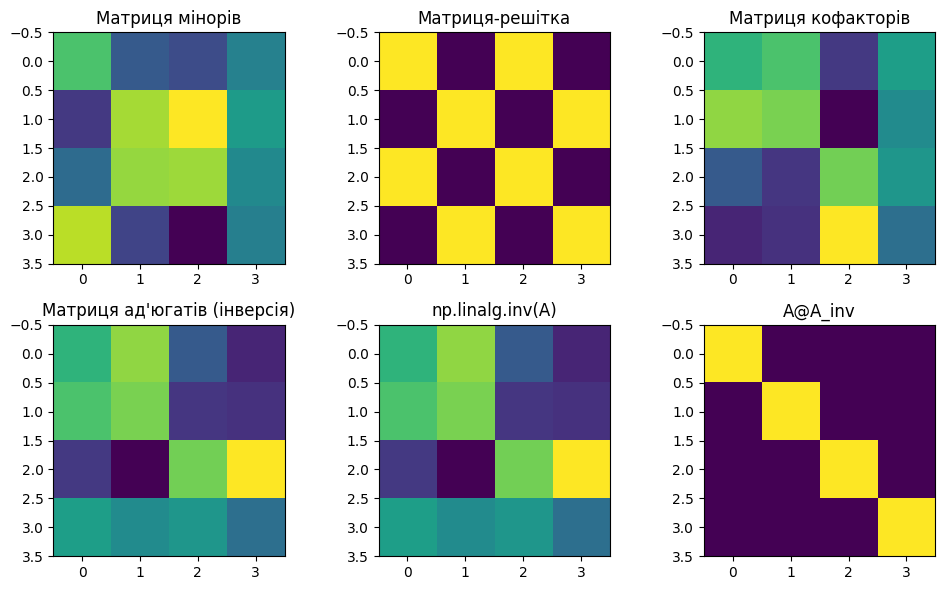

In [125]:
matrices = [
    ("Mатриця мінорів", M),
    ("Матриця-решітка", G),
    ("Матриця кофакторів", K),
    ("Матриця ад'югатів (інверсія)", A_inv),
    ("np.linalg.inv(A)", A_inv_np),
    ("A@A_inv",A@A_inv)
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, (name, mat) in zip(axes.flatten(), matrices):
    im = ax.imshow(mat)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Завдання 8.3

In [126]:
a = random.randint(0, 9)
b = random.randint(0, 9)
c = random.randint(0, 9)
d = random.randint(0, 9)
print(f"Матриця A:\n[[{a}, {b}],\n [{c}, {d}]]\n")
det = a*d - b*c

if det == 0:
    print("Матриця не має оберненої, бо det = 0")
else:
    A_inv = [[d/det, -b/det],
             [-c/det, a/det]]
    
    print("Обернена матриця A⁻¹:")
    for row in A_inv:
        print([round(x, 2) for x in row])


Матриця A:
[[6, 8],
 [6, 9]]

Обернена матриця A⁻¹:
[1.5, -1.33]
[-1.0, 1.0]


### Завдання 8.4

WR = 
 [[ 1.  0. -0.  0.]
 [-0.  1.  0. -0.]
 [ 0.  0.  1. -0.]
 [-0.  0.  0.  1.]]
RW = 
 [[ 0.09 -0.01 -0.02 ... -0.04  0.07  0.03]
 [-0.01  0.1  -0.07 ...  0.03  0.08 -0.02]
 [-0.02 -0.07  0.08 ... -0.04 -0.08 -0.03]
 ...
 [-0.04  0.03 -0.04 ...  0.14 -0.02  0.  ]
 [ 0.07  0.08 -0.08 ... -0.02  0.12  0.02]
 [ 0.03 -0.02 -0.03 ...  0.    0.02  0.09]]


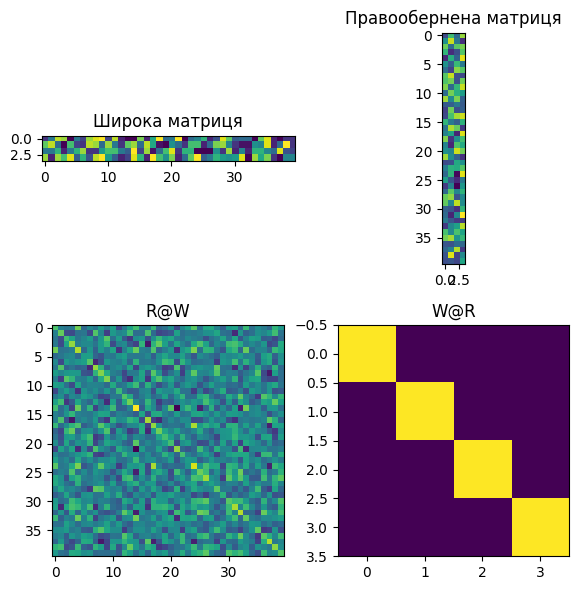

In [127]:
W = np.random.randint(-10, 11, size=(4, 40)) # широка матриця
WWt = W @ W.T # квадратна 
WWt_inv = np.linalg.inv(WWt)
R = W.T @ WWt_inv #правообернена матриця
print ("WR = \n",np.round(W@R,2))
print ("RW = \n",np.round(R@W,2))

fig,axs = plt.subplots(2,2,figsize=(6,6))

axs[0,0].imshow(W,cmap='viridis')
axs[0,0].set_title('Широка матриця')

axs[0,1].imshow(R,cmap='viridis')
axs[0,1].set_title('Правообернена матриця')

axs[1,0].imshow(R@W,cmap='viridis')
axs[1,0].set_title('R@W')

axs[1,1].imshow(W@R,cmap='viridis')
axs[1,1].set_title('W@R')

plt.tight_layout()
plt.show()

### Завдання 8.5

In [102]:
n = 4
A = np.random.randn(n, n) 

A_inv = np.linalg.inv(A)     # стандартна обернена матриця
A_pinv = np.linalg.pinv(A)   # псевдообернена матриця Мура-Пенроуза

print("Повна обернена матриця = псевдооберненій матриці:", np.allclose(A_inv,A_pinv))

m, n = 12, 3
B = np.random.randn(m, n)   # високa матриця

B_left = np.linalg.inv(B.T @ B) @ B.T  
B_pinv = np.linalg.pinv(B)            

print("Лівообернена матриця = псевдооберненій матриці:", np.allclose(B_left,B_pinv))

m, n = 3, 12
C = np.random.randn(m, n)   # широка матриця

C_right = C.T @ np.linalg.inv(C @ C.T)  
C_pinv = np.linalg.pinv(C)              

print("Правообернена матриця = псевдооберненій матриці:", np.allclose(C_right,C_pinv))

Повна обернена матриця = псевдооберненій матриці: True
Лівообернена матриця = псевдооберненій матриці: True
Правообернена матриця = псевдооберненій матриці: True


### Завдання 8.6

In [134]:
n = 4
A = np.random.randn(n,n)
B = np.random.randn(n,n)

op1 = np.linalg.inv(A @ B)
op2 = np.linalg.inv(A) @ np.linalg.inv(B)
op3 = np.linalg.inv(B) @ np.linalg.inv(A)

dist12 = np.sqrt(np.sum((op1 - op2)**2))
dist13 = np.sqrt(np.sum((op1 - op3)**2))

print(f'Відстань між (AB)⁻¹ і (A⁻¹)(B⁻¹) = {dist12:.3f}')
print(f'Відстань між (AB)⁻¹ і (B⁻¹)(A⁻¹) = {dist13:.3f}')

Відстань між (AB)⁻¹ і (A⁻¹)(B⁻¹) = 24.393
Відстань між (AB)⁻¹ і (B⁻¹)(A⁻¹) = 0.000


### Завдання 8.7

In [ ]:
m,n = 2,16
T = np.random.randn(m,n)

a = np.linalg.inv(T.T@T)
b = np.linalg.inv(T) @ np.linalg.inv(T.T)

# не працює, бо  висока матриця не має оберненої

LinAlgError: Last 2 dimensions of the array must be square